<a href="https://colab.research.google.com/github/Maryam-Skaik/ml-classification-pipeline/blob/main/Classification_Metrics_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Metrics (Core)

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load Dataset

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Week07/Data/stroke.csv'
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


## Data Inspection

In [ ]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True))

stroke
0    1000
1     137
Name: count, dtype: int64
stroke
0    0.879507
1    0.120493
Name: proportion, dtype: float64


## Define Features (X) and Target (y)

In [ ]:
y = df['stroke']
X = df.drop(columns='stroke')

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

stroke
0    749
1    103
Name: count, dtype: int64
stroke
0    0.879108
1    0.120892
Name: proportion, dtype: float64


## Build Preprocessing Pipeline

In [ ]:
# Identify column types
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Numeric pipeline
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

ohe = OneHotEncoder(handle_unknown='ignore')

# Combine both
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', ohe, cat_cols)])

## Build and Train Model Pipeline

In [ ]:
model = DecisionTreeClassifier(random_state=42)

pipe = make_pipeline(preprocessor, model)

pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

## Evaluate Model

In [ ]:
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray', colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap, colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()

  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test, figsize=(6,4), normalize='true', output_dict = False, cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, output_dict=True, figsize=figsize, colorbar=colorbar, cmap=cmap_train, label='Training Data')
  print()

  # Get predictions for test data
  y_test_pred = model.predict(X_test)

  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, output_dict=True,figsize=figsize, colorbar=colorbar, cmap=cmap_test, label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train, 'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: 
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       251
           1       0.30      0.29      0.30        34

    accuracy                           0.84       285
   macro avg       0.60      0.60      0.60       285
weighted avg       0.83      0.84      0.83       285



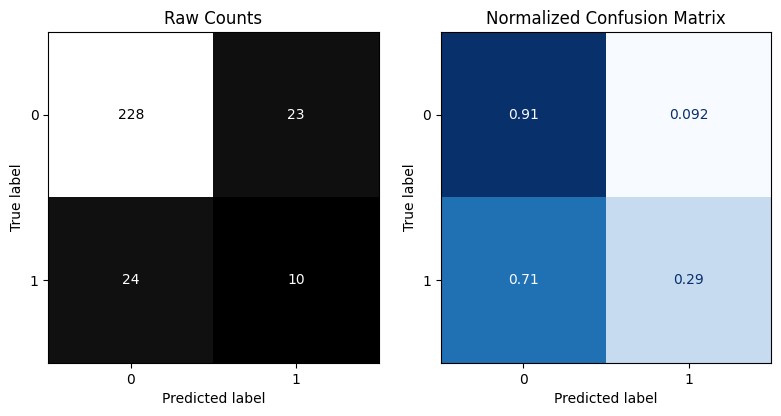

In [ ]:
classification_metrics(y_test, pipe.predict(X_test))

## Confusion Matrix Values

In [ ]:
cm = confusion_matrix(y_test, pipe.predict(X_test))

TN, FP, FN, TP = cm.ravel()

TN, FP, FN, TP

(np.int64(228), np.int64(23), np.int64(24), np.int64(10))

## Compute Key Metrics

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)


accuracy, false_positive_rate, false_negative_rate

(np.float64(0.8350877192982457),
 np.float64(0.09163346613545817),
 np.float64(0.7058823529411765))

## 1) Overall Accuracy
The model achieved an accuracy of approximately **83.5%**. While this appears to be a strong performance at first glance, it can be misleading in the context of class imbalance. Since stroke datasets typically contain many more non-stroke cases than stroke cases, a high accuracy does not necessarily indicate that the model is effective at identifying stroke patients. In this case, the model’s performance is not reliable for medical decision-making because accuracy alone does not reflect how well it detects the positive (stroke) class.

---

## 2) False Positive Rate (Unnecessary Stroke Alerts)
Approximately **9.16%** of patients who did not have a stroke were incorrectly predicted as having a stroke. This means that around 9% of healthy individuals would receive unnecessary stroke alerts, which could lead to additional medical tests, stress, and anxiety. However, in a medical context, false positives are generally less dangerous than missing actual stroke cases.

---

## 3) False Negative Rate (Missed Stroke Cases)
Approximately **70.6%** of patients who actually had a stroke were incorrectly predicted as not having a stroke. This is a very high and critical error rate, meaning the model fails to detect most true stroke cases. In real-world medical applications, this is extremely dangerous because it may prevent patients from receiving urgent and potentially life-saving treatment.

---

## 4) Most Important Metric to Optimize
The most important metric to optimize in this problem is **recall**. Recall focuses on correctly identifying all actual positive cases and directly reduces false negatives. In the context of stroke detection, missing a positive case is far more harmful than generating a false alarm. Therefore, improving recall is essential even if it increases false positives or slightly reduces overall accuracy, because the priority is to ensure that as many real stroke cases as possible are detected.